# **Knee Osteoarthritis Classification using Transfer Learning**

**Overview**

This project aims to classify knee osteoarthritis severity from X-ray images using deep learning.

A pretrained ResNet18 model was fine-tuned to classify five Kellgren-Lawrence (KL) grades:

- Grade 0: Healthy
- Grade 1: Doubtful
- Grade 2: Minimal OA
- Grade 3: Moderate OA
- Grade 4: Severe OA

Several experiments were conducted to evaluate the effect of class weighting and fine-tuning strategies.

**Import Libraries**

In [1]:
import os
from torchvision import transforms
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**Dataset**

The dataset contains five classes representing different stages of knee osteoarthritis severity based on Kellgren-Lawrence grading.

**Class Labels**

The original numeric labels were converted into clinically meaningful Kellgren-Lawrence grade names for result interpretation.

In [3]:
class_names = [
    "Healthy",
    "Doubtful",
    "Minimal",
    "Moderate",
    "Severe"
]

In [4]:
train_path = "/content/drive/My Drive/knee project/data/archive/train"
val_path = "/content/drive/My Drive/knee project/data/archive/val"
test_path = "/content/drive/My Drive/knee project/data/archive/test"

In [5]:
print("Train exists:", os.path.exists(train_path))
print("Val exists:", os.path.exists(val_path))
print("Test exists:", os.path.exists(test_path))

Train exists: True
Val exists: True
Test exists: True


**Data Preprocessing and Transformation**

Images were resized to 224×224 pixels and normalized using ImageNet statistics to match the pretrained ResNet18 input requirements.

In [6]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

**Dataset Exploration**

The dataset contains five classes corresponding to different Kellgren-Lawrence grades of knee osteoarthritis.

Before model training, the class distribution was analyzed to evaluate potential class imbalance.

In [7]:
train_dataset = datasets.ImageFolder(
    root = train_path,
    transform = val_test_transform
)

val_dataset = datasets.ImageFolder(
    root = val_path,
    transform = val_test_transform
)

test_dataset = datasets.ImageFolder(
    root = test_path,
    transform = val_test_transform
)


**Class Distribution**

| Class | Grade    | Train | Validation |
| ----- | -------- | ----: | ---------: |
| 0     | Healthy  |  2286 |        328 |
| 1     | Doubtful |  1046 |        165 |
| 2     | Minimal  |  1516 |        212 |
| 3     | Moderate |   757 |        106 |
| 4     | Severe   |   173 |         27 |


**DataLoader**

DataLoaders were created to efficiently load batches of images during training, validation, and testing.

The training process uses mini-batch optimization to update model parameters.

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)


In [9]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(images.shape)
print(labels.shape)



torch.Size([8, 3, 224, 224])
torch.Size([8])


In [10]:
print(labels)

tensor([2, 2, 3, 2, 1, 2, 1, 0])


**Sample Image Visualization**

A sample image was visualized after reversing normalization to verify that preprocessing was applied correctly.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

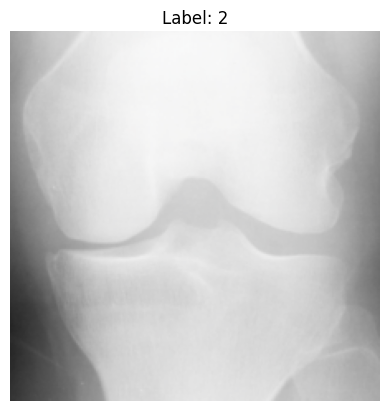

In [11]:
image = images[0]
label = labels[0]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = image.permute(1, 2, 0).numpy()
image = std * image + mean
image = np.clip(image, 0, 1)

plt.imshow(image)
plt.title(f"Label: {label.item()}")
plt.axis("off")

# **Experiment 1: Transfer Learning Baseline (Frozen ResNet18)**

**Objective**

The first experiment establishes a baseline model using transfer learning with a pretrained ResNet18 network.

Only the final fully connected layer is modified for five-class knee osteoarthritis severity classification.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18 (pretrained = True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


**Feature Extractor Freezing**

To establish a baseline transfer learning approach, all pretrained ResNet18 layers were frozen. Only the final fully connected classification layer was trained for five-class osteoarthritis severity prediction.

In [ ]:
for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True

model = model.to(device)

In [ ]:
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Trainable parameters: 2,565
Total parameters: 11,179,077


**Loss Function and Optimizer**

The model was trained using Cross-Entropy Loss for multi-class classification.

The Adam optimizer was used to update the trainable parameters of the classification layer.

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

**Model Training**

The model was trained using mini-batch gradient descent.

During each iteration:
1. Images and labels were transferred to the computational device.
2. Forward propagation was performed.
3. Cross-entropy loss was calculated.
4. Model parameters were updated using backpropagation and Adam optimizer.

Training loss was monitored across epochs.

In [ ]:
num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} finished | Avg Loss: {epoch_loss:.4f}"
    )

Epoch 1, Step 0, Loss: 1.7403
Epoch 1, Step 20, Loss: 1.3811
Epoch 1, Step 40, Loss: 1.1432
Epoch 1, Step 60, Loss: 1.5768
Epoch 1, Step 80, Loss: 1.8233
Epoch 1, Step 100, Loss: 1.1825
Epoch 1, Step 120, Loss: 1.5590
Epoch 1, Step 140, Loss: 1.5202
Epoch 1, Step 160, Loss: 1.4976
Epoch 1, Step 180, Loss: 1.1937
Epoch 1, Step 200, Loss: 1.4507
Epoch 1, Step 220, Loss: 1.9510
Epoch 1, Step 240, Loss: 1.5574
Epoch 1, Step 260, Loss: 1.2540
Epoch 1, Step 280, Loss: 1.1066
Epoch 1, Step 300, Loss: 1.3439
Epoch 1, Step 320, Loss: 1.5332
Epoch 1, Step 340, Loss: 1.2706
Epoch 1, Step 360, Loss: 1.3245
Epoch 1, Step 380, Loss: 1.2498
Epoch 1, Step 400, Loss: 0.7985
Epoch 1, Step 420, Loss: 1.1361
Epoch 1, Step 440, Loss: 1.1304
Epoch 1, Step 460, Loss: 1.2573
Epoch 1, Step 480, Loss: 1.6029
Epoch 1, Step 500, Loss: 1.1026
Epoch 1, Step 520, Loss: 1.6503
Epoch 1, Step 540, Loss: 1.6622
Epoch 1, Step 560, Loss: 1.1256
Epoch 1, Step 580, Loss: 1.5031
Epoch 1, Step 600, Loss: 1.4645
Epoch 1, Step 

**Model Evaluation**

After training, the model was evaluated on the validation dataset.

Performance was assessed using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

In [ ]:
model.eval()

model = model.to(device)

correct = 0
total = 0

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print (f"Validation Accuracy: {accuracy: .2f}%")

Validation Accuracy:  43.56%


**Generate Validation Predictions**

Model predictions were collected from the validation set for performance analysis.

In [ ]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())


**Confusion Matrix**

The confusion matrix was used to analyze class-specific prediction errors and identify misclassification patterns between osteoarthritis grades.

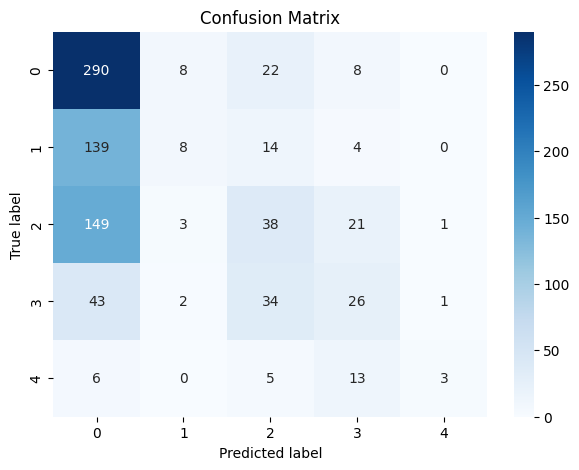

In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.savefig("exp1_confusion_matrix.png",dpi=300,bbox_inches="tight")

plt.show()

**Classification Report**

Precision, recall, and F1-score were calculated for each osteoarthritis severity grade.

In [ ]:
report = classification_report(
    all_labels,
    all_predictions,
    digits=4,
    target_names=class_names,
    output_dict = True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Healthy,0.462520,0.884146,0.607330,328.000000
Doubtful,0.380952,0.048485,0.086022,165.000000
Minimal,0.336283,0.179245,0.233846,212.000000
Moderate,0.361111,0.245283,0.292135,106.000000
Severe,0.600000,0.111111,0.187500,27.000000
accuracy,0.435561,0.435561,0.435561,0.435561
macro avg,0.428173,0.293654,0.281366,838.000000
weighted avg,0.406126,0.435561,0.356804,838.000000


## Experiment 1 Results

The baseline transfer learning approach achieved an accuracy of 43.56%.

The confusion matrix showed that the model performed better in distinguishing healthy samples, while neighboring osteoarthritis grades showed higher confusion.
The classification between adjacent osteoarthritis grades remained challenging due to subtle radiographic differences.

# **Experiment 2: Class-Weighted Loss**

**Motivation**

The baseline model (Experiment 1) showed limited performance for some osteoarthritis severity grades.

Since the dataset contains an unequal number of samples across classes, a class-weighted loss strategy was applied to reduce the impact of class imbalance and encourage the model to pay more attention to underrepresented classes.

**Model Definition**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18 (pretrained = True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**Featur Extractor Freezing**

In [ ]:
for param in model.parameters():
  param.requires_grad = False

for param in model.fc.parameters():
  param.requires_grad = True

model = model.to(device)

**Computing Class Weights**

In [ ]:
train_labels = np.array(train_dataset.targets)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

print(weights)

[0.50586177 1.10554493 0.76279683 1.52358366 6.608     ]


**Weighted Cross-Entropy Loss**

Class weights were incorporated into the cross-entropy loss function to penalize misclassification of underrepresented classes more strongly.

In [ ]:
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(class_weights)

tensor([0.5059, 1.1055, 0.7628, 1.5236, 6.6080], device='cuda:0')


**Optimizer**

The Adam optimizer was used with the same learning rate as the baseline experiment.

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

**Model Training**

In [ ]:
epochs = 3

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} finished | Avg Loss: {epoch_loss:.4f}"
    )

Epoch 1, Step 0, Loss: 1.6355
Epoch 1, Step 20, Loss: 1.2122
Epoch 1, Step 40, Loss: 1.6680
Epoch 1, Step 60, Loss: 1.3874
Epoch 1, Step 80, Loss: 1.4583
Epoch 1, Step 100, Loss: 1.4654
Epoch 1, Step 120, Loss: 1.4887
Epoch 1, Step 140, Loss: 1.4293
Epoch 1, Step 160, Loss: 1.5127
Epoch 1, Step 180, Loss: 1.2948
Epoch 1, Step 200, Loss: 1.3737
Epoch 1, Step 220, Loss: 1.5470
Epoch 1, Step 240, Loss: 0.9238
Epoch 1, Step 260, Loss: 2.3099
Epoch 1, Step 280, Loss: 1.7281
Epoch 1, Step 300, Loss: 1.5204
Epoch 1, Step 320, Loss: 1.3511
Epoch 1, Step 340, Loss: 1.8859
Epoch 1, Step 360, Loss: 1.9830
Epoch 1, Step 380, Loss: 1.6369
Epoch 1, Step 400, Loss: 2.3385
Epoch 1, Step 420, Loss: 1.3451
Epoch 1, Step 440, Loss: 1.2964
Epoch 1, Step 460, Loss: 1.2862
Epoch 1, Step 480, Loss: 1.3085
Epoch 1, Step 500, Loss: 1.4130
Epoch 1, Step 520, Loss: 1.3147
Epoch 1, Step 540, Loss: 1.6737
Epoch 1, Step 560, Loss: 1.3545
Epoch 1, Step 580, Loss: 1.4183
Epoch 1, Step 600, Loss: 1.1690
Epoch 1, Step 

**Model Evaluation**

In [ ]:
model.eval()

model = model.to(device)

correct = 0
total = 0

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print (f"Validation Accuracy: {accuracy: .2f}%")

Validation Accuracy:  31.98%


**Generate Validation Predictions**

In [ ]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())


**Confusion Matrix**

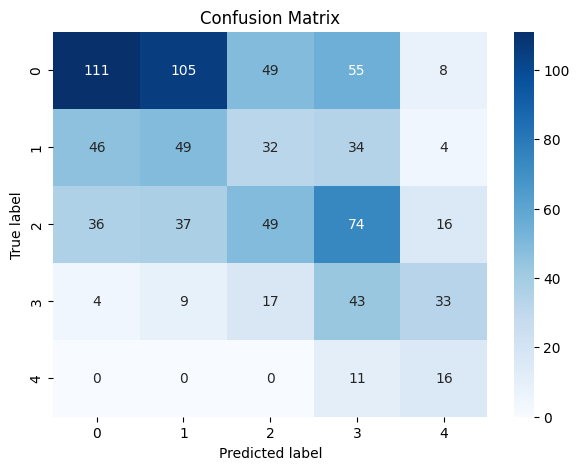

In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.savefig("exp2_confusion_matrix.png",dpi=300,bbox_inches="tight")

plt.show()

**Classification Report**

In [ ]:
report = classification_report(
    all_labels,
    all_predictions,
    digits=4,
    target_names=class_names,
    output_dict = True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Healthy,0.563452,0.338415,0.422857,328.000000
Doubtful,0.245000,0.296970,0.268493,165.000000
Minimal,0.333333,0.231132,0.272981,212.000000
Moderate,0.198157,0.405660,0.266254,106.000000
Severe,0.207792,0.592593,0.307692,27.000000
accuracy,0.319809,0.319809,0.319809,0.319809
macro avg,0.309547,0.372954,0.307655,838.000000
weighted avg,0.384867,0.319809,0.331027,838.000000


## Experiment 2 Summary

Applying class-weighted cross-entropy encouraged the model to pay greater attention to underrepresented osteoarthritis grades.

Performance was compared with the baseline experiment to evaluate the effect of class imbalance handling.

# **Experiment 3: Fine-Tuning with Class-Weighted Loss**

**Motivation**

The baseline model used only the pretrained feature extractor with a trainable classification head.

In this experiment, the last residual block (layer4) was unfrozen to allow the network to learn knee X-ray-specific features while preserving pretrained low-level representations.

**Model Definition and Fine-Tuning Strategy**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = models.resnet18(weights="IMAGENET1K_V1")

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classification head
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Train FC layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


**Computing Class Weights**

In [ ]:
train_labels = np.array(train_dataset.targets)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

print(weights)

[0.50586177 1.10554493 0.76279683 1.52358366 6.608     ]


**Weighted Cross-Entropy Loss**

Class weights were incorporated into the cross-entropy loss function to penalize misclassification of underrepresented classes more strongly.

In [ ]:
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(class_weights)

tensor([0.5059, 1.1055, 0.7628, 1.5236, 6.6080], device='cuda:0')


**Optimizer**

The Adam optimizer was used with the same learning rate as the baseline experiment.

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

**Model Training**

In [ ]:
epochs = 3

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} finished | Avg Loss: {epoch_loss:.4f}"
    )

Epoch 1, Step 0, Loss: 1.8753
Epoch 1, Step 20, Loss: 1.9508
Epoch 1, Step 40, Loss: 1.5306
Epoch 1, Step 60, Loss: 1.0523
Epoch 1, Step 80, Loss: 1.4270
Epoch 1, Step 100, Loss: 1.0715
Epoch 1, Step 120, Loss: 1.5446
Epoch 1, Step 140, Loss: 1.2723
Epoch 1, Step 160, Loss: 1.5932
Epoch 1, Step 180, Loss: 1.0876
Epoch 1, Step 200, Loss: 1.3178
Epoch 1, Step 220, Loss: 0.8578
Epoch 1, Step 240, Loss: 1.1391
Epoch 1, Step 260, Loss: 1.6424
Epoch 1, Step 280, Loss: 1.6379
Epoch 1, Step 300, Loss: 1.2646
Epoch 1, Step 320, Loss: 1.0345
Epoch 1, Step 340, Loss: 1.0788
Epoch 1, Step 360, Loss: 1.2890
Epoch 1, Step 380, Loss: 1.0321
Epoch 1, Step 400, Loss: 1.1350
Epoch 1, Step 420, Loss: 1.0041
Epoch 1, Step 440, Loss: 1.3278
Epoch 1, Step 460, Loss: 1.4991
Epoch 1, Step 480, Loss: 1.1503
Epoch 1, Step 500, Loss: 0.9640
Epoch 1, Step 520, Loss: 1.1714
Epoch 1, Step 540, Loss: 1.0558
Epoch 1, Step 560, Loss: 1.9634
Epoch 1, Step 580, Loss: 0.6470
Epoch 1, Step 600, Loss: 1.0593
Epoch 1, Step 

**Model Evaluation**

In [ ]:
model.eval()

model = model.to(device)

correct = 0
total = 0

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print (f"Validation Accuracy: {accuracy: .2f}%")

Validation Accuracy:  49.40%


**Generate Validation Predictions**

In [ ]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())


**Confusion Matrix**

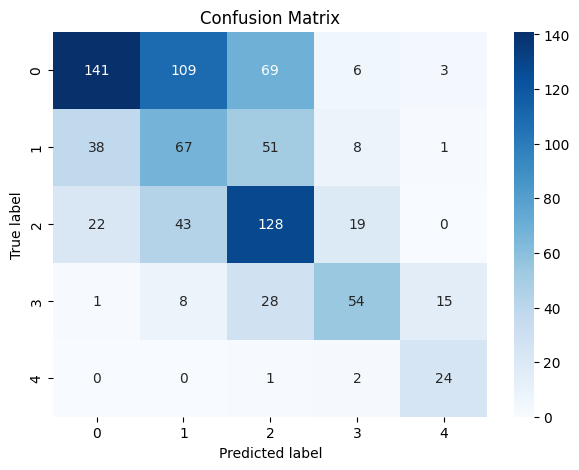

In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.savefig("exp3_confusion_matrix.png",dpi=300,bbox_inches="tight")

plt.show()

**Classification Report**

In [ ]:
report = classification_report(
    all_labels,
    all_predictions,
    digits=4,
    target_names=class_names,
    output_dict = True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Healthy,0.698020,0.429878,0.532075,328.000000
Doubtful,0.295154,0.406061,0.341837,165.000000
Minimal,0.462094,0.603774,0.523517,212.000000
Moderate,0.606742,0.509434,0.553846,106.000000
Severe,0.558140,0.888889,0.685714,27.000000
accuracy,0.494033,0.494033,0.494033,0.494033
macro avg,0.524030,0.567607,0.527398,838.000000
weighted avg,0.542958,0.494033,0.500157,838.000000


## Experiment 3 Summary

Fine-tuning the last residual block allowed the pretrained ResNet18 to adapt more effectively to knee X-ray characteristics.

Compared with the baseline experiment, this approach improved discrimination between osteoarthritis grades, particularly for moderate and severe cases.

Although class weighting improved recall for minority classes, it reduced overall classification performance, suggesting that aggressive re-balancing may not be optimal for this dataset.

| Model                 | Accuracy | Macro F1 |
| --------------------- | -------- | -------- |
| Baseline              | 43.56    | 0.28   |
| Weighted              | 31.98     | 0.30    |
| Fine-tuned + Weighted | 49.40     | 0.52   |


# **Experiment 4: Fine-Tuning with Standard Cross-Entropy Loss**

**Motivation**

To evaluate the independent effect of fine-tuning, the model was fine-tuned using the last residual block (layer4) without applying class-weighted loss.

The results were compared with Experiment 3 to determine whether performance improvements were mainly caused by fine-tuning or class imbalance handling.

**Model Definition and Fine-tuning Strategy**

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="IMAGENET1K_V1")

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


**Standard Cross-Entropy Loss**

In [13]:
criterion = nn.CrossEntropyLoss()

**Optimizer**

The Adam optimizer was used with the same learning rate as the baseline experiment.

In [14]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

**Model Training**

In [15]:
epochs = 3

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1} finished | Avg Loss: {epoch_loss:.4f}"
    )

Epoch 1, Step 0, Loss: 1.6936
Epoch 1, Step 20, Loss: 1.7663
Epoch 1, Step 40, Loss: 1.4155
Epoch 1, Step 60, Loss: 1.3914
Epoch 1, Step 80, Loss: 1.3972
Epoch 1, Step 100, Loss: 1.3636
Epoch 1, Step 120, Loss: 1.4474
Epoch 1, Step 140, Loss: 1.7505
Epoch 1, Step 160, Loss: 1.7223
Epoch 1, Step 180, Loss: 1.1816
Epoch 1, Step 200, Loss: 1.0450
Epoch 1, Step 220, Loss: 1.0470
Epoch 1, Step 240, Loss: 1.0241
Epoch 1, Step 260, Loss: 1.1206
Epoch 1, Step 280, Loss: 1.3227
Epoch 1, Step 300, Loss: 1.1912
Epoch 1, Step 320, Loss: 1.0092
Epoch 1, Step 340, Loss: 1.3675
Epoch 1, Step 360, Loss: 0.6848
Epoch 1, Step 380, Loss: 0.7773
Epoch 1, Step 400, Loss: 1.3469
Epoch 1, Step 420, Loss: 1.4504
Epoch 1, Step 440, Loss: 0.9367
Epoch 1, Step 460, Loss: 0.9694
Epoch 1, Step 480, Loss: 0.8595
Epoch 1, Step 500, Loss: 1.0051
Epoch 1, Step 520, Loss: 1.2417
Epoch 1, Step 540, Loss: 1.4194
Epoch 1, Step 560, Loss: 1.0728
Epoch 1, Step 580, Loss: 0.7470
Epoch 1, Step 600, Loss: 0.9231
Epoch 1, Step 

In [16]:
save_dir = "/content/drive/My Drive/knee project/models"
os.makedirs(save_dir, exist_ok=True)

torch.save(
    model.state_dict(),
    os.path.join(save_dir, "exp4_best_resnet18.pth")
)

print("Best model saved successfully!")

Best model saved successfully!


**Model Evaluation**

In [17]:
model.eval()

model = model.to(device)

correct = 0
total = 0

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print (f"Validation Accuracy: {accuracy: .2f}%")

Validation Accuracy:  50.12%


**Generate Validation Predictions**

In [18]:
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
  for images, labels in val_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

    all_labels.extend(labels.cpu().numpy())
    all_predictions.extend(predicted.cpu().numpy())


**Confusion Matrix**

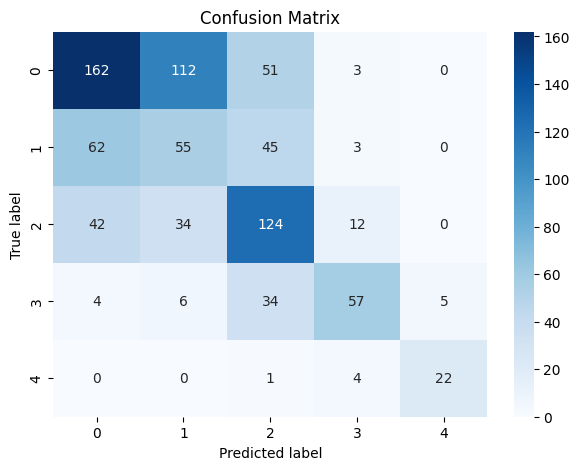

In [19]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")

plt.savefig("exp4_confusion_matrix.png",dpi=300,bbox_inches="tight")

plt.show()

**Classification Report**

In [20]:
report = classification_report(
    all_labels,
    all_predictions,
    digits=4,
    target_names=class_names,
    output_dict = True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Healthy,0.600000,0.493902,0.541806,328.000000
Doubtful,0.265700,0.333333,0.295699,165.000000
Minimal,0.486275,0.584906,0.531049,212.000000
Moderate,0.721519,0.537736,0.616216,106.000000
Severe,0.814815,0.814815,0.814815,27.000000
accuracy,0.501193,0.501193,0.501193,0.501193
macro avg,0.577662,0.552938,0.559917,838.000000
weighted avg,0.527699,0.501193,0.508835,838.000000


## Experiment 4 Summary

This experiment evaluated the effect of fine-tuning without class-weighted loss.

By comparing this experiment with Experiment 3, the contribution of class weighting to performance improvement can be assessed.